# Experiment: 2D cond 1D

dim(x)=1, dim(y)=1 — comparing LGD vs LGD-CM.

In [ ]:
import os
# ============================================================
# CONFIG — only this cell changes between notebooks
# Structure:
#   simulations/src/        ← all .py modules
#   simulations/notebooks/  ← this notebook
#   simulations/params/     ← canonical GMM parameters (shared, load first)
#   simulations/checkpoints/
#   simulations/results/
# ============================================================
EXPERIMENT_NAME   = "2D_cond_1D"
GLOBAL_SEED       = 42
FORCE_RETRAIN     = False

BASE_DIR = os.path.normpath(os.path.join(os.getcwd(), ".."))
PARAMS_DIR        = f"{BASE_DIR}/params"
CHECKPOINT_DIR    = f"{BASE_DIR}/checkpoints/{EXPERIMENT_NAME}"
RESULTS_DIR       = f"{BASE_DIR}/results/{EXPERIMENT_NAME}"

# Architecture — Diffusion models
NBLOCKS           = 3
NUNITS            = 128

# Architecture — Consistency Model (separate so it can be scaled independently)
NBLOCKS_CM        = 3
NUNITS_CM         = 128

# Training — Diffusion
NEPOCHS           = 20_000
BATCH_SIZE        = 1_024

# Training — Consistency Model
NEPOCHS_CM        = 20_000
BATCH_SIZE_CM     = 1_024

# Diffusion
DIFFUSION_STEPS   = 100

# Optimization
N_ATTEMP_OPTIM              = 25
NSAMPLES_IN_OPTIM_FOR_MMD   = 250
NUM_X_T_LGD                 = 3
NUM_X_T_LGD_CM              = 3

# GMM dimensions
CONDITION_ON      = 1   # dim(x)=1, dim(y)=1

In [ ]:
import os, sys

# ── point Python at simulations/src where all .py modules live ──
src_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "src")
src_path = os.path.normpath(src_path)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"src path on sys.path: {src_path}")

In [ ]:
# Install dependencies if needed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "flow_matching", "POT", "-q"])

In [ ]:
import os, sys, time, json
import importlib
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange

import Diffusion
import LossFunctions
import ConsistencyModels
import dist_utils
import Optimization
import experiment_utils
from ConsistencyModels import ConsistencyModeliCT
from LossFunctions import MMDLoss, RBF

for mod in [Diffusion, LossFunctions, ConsistencyModels,
            dist_utils, Optimization, experiment_utils]:
    importlib.reload(mod)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)
os.makedirs(PARAMS_DIR,     exist_ok=True)
print("Imports done.")

Imports done.


In [ ]:
env_info = experiment_utils.get_environment_info()
experiment_utils.print_environment_info(env_info)

ENVIRONMENT INFO
  timestamp: 2026-04-27T09:04:42.103393
  torch_version: 2.10.0+cu128
  cuda_available: True
  cuda_version: 12.8
  device_name: Tesla T4
  packages:
    torch: 2.10.0+cu128
    numpy: 2.0.2
    flow_matching: 1.0.10
    POT: 0.9.6.post1
    matplotlib: 3.10.0
    pandas: 2.2.2
    tqdm: 4.67.3


In [ ]:
experiment_utils.set_global_seed(GLOBAL_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[Seed] All random seeds set to 42
Using device: cuda


## GMM Parameters

In [ ]:
# ============================================================
# GMM PARAMETERS
# Priority:
#   1. Load from PARAMS_DIR  (shared across runs, committed to repo)
#   2. Load from RESULTS_DIR (fallback from a previous run)
#   3. Generate fresh and save to both dirs
#
# To force regeneration: set FORCE_REGENERATE_PARAMS = True
# ============================================================
FORCE_REGENERATE_PARAMS = False

def _load_params():
    """Try PARAMS_DIR first, then RESULTS_DIR."""
    loaded = experiment_utils.load_gmm_params(PARAMS_DIR, EXPERIMENT_NAME)
    if loaded is not None:
        print(f"[GMM] Loaded from PARAMS_DIR: {PARAMS_DIR}")
        return loaded
    loaded = experiment_utils.load_gmm_params(RESULTS_DIR, EXPERIMENT_NAME)
    if loaded is not None:
        print(f"[GMM] Loaded from RESULTS_DIR: {RESULTS_DIR}")
        return loaded
    return None

loaded = None if FORCE_REGENERATE_PARAMS else _load_params()

if loaded is not None:
    mu_list, Sigma_list, alpha, mog_means, mog_variances, weights, x_star = loaded
    mu_list    = [mu.float() for mu in mu_list]
    Sigma_list = [cov.float() for cov in Sigma_list]
    alpha      = alpha.float()
else:
    print("[GMM] Generating fresh parameters...")
    experiment_utils.set_global_seed(GLOBAL_SEED)   # seed generation for reproducibility
    mu_list = [
        torch.tensor([-5,  5], dtype=torch.float64),
        torch.tensor([-5, -5], dtype=torch.float64),
        torch.tensor([ 5,  3], dtype=torch.float64),
        torch.tensor([ 5, -1], dtype=torch.float64),
        torch.tensor([ 0, -3], dtype=torch.float64),
        torch.tensor([-2,  4], dtype=torch.float64),
        torch.tensor([-2, -3], dtype=torch.float64),
        torch.tensor([ 1,  2], dtype=torch.float64),
        torch.tensor([-8,  1], dtype=torch.float64),
        torch.tensor([ 7,  5], dtype=torch.float64),
        torch.tensor([ 0, -5], dtype=torch.float64),
    ]
    Sigma_list = [
        torch.tensor([[0.5000, 0.1950],
                      [0.1950, 0.2000]], dtype=torch.float64)
    ] * len(mu_list)
    alpha = torch.tensor([1 / len(mu_list)] * len(mu_list), dtype=torch.float64)

    mu_list    = [mu.float() for mu in mu_list]
    Sigma_list = [cov.float() for cov in Sigma_list]
    alpha      = alpha.float()

    x_star = torch.tensor([-5])
    mu_temp, Sigma_temp = dist_utils.compute_conditionals(mu_list, Sigma_list, x_star)
    temp_alpha          = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star)
    mog_means, mog_variances, weights = dist_utils.filter_and_normalize(
        mu_temp, Sigma_temp, temp_alpha, threshold=0.01
    )

    # save to PARAMS_DIR (canonical, share across runs)
    experiment_utils.save_gmm_params(
        mu_list, Sigma_list, alpha,
        mog_means, mog_variances, weights, x_star,
        PARAMS_DIR, EXPERIMENT_NAME
    )

print(f"x_star = {x_star}")
print(f"Number of conditional modes after filtering: {len(mog_means)}")

[GMM] Parameters loaded from /content/conditional-matching-paper/simulations/params/2D_cond_1D_gmm_params.pt
[GMM] Loaded from PARAMS_DIR: /content/conditional-matching-paper/simulations/params
x_star = tensor([-5])
Number of conditional modes after filtering: 2


## Data

[Seed] All random seeds set to 42


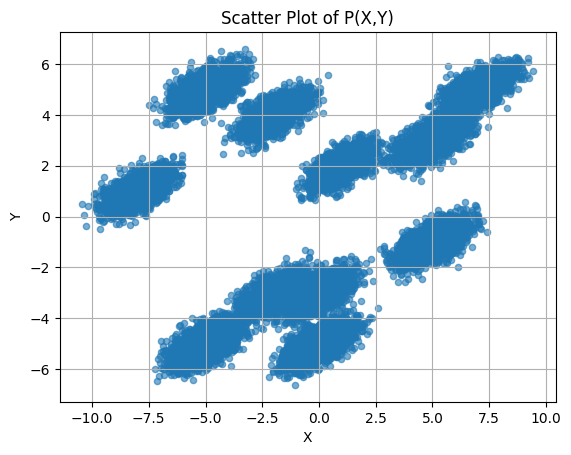

In [ ]:
experiment_utils.set_global_seed(GLOBAL_SEED)
X = dist_utils.generate_mog_samples(25_000, mu_list, Sigma_list, alpha).float().to(device)
xh_cpu = X.detach().cpu().numpy()
plt.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.6, s=20)
plt.title("Scatter Plot of P(X,Y)")
plt.xlabel("X"); plt.ylabel("Y"); plt.grid(True); plt.show()

## Train Models

### Consistency Model — P(Y|X=x)

In [ ]:
experiment_utils.set_global_seed(GLOBAL_SEED)

B, C      = X.shape
nfeatures = C - CONDITION_ON
data_generator_cm = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha
)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON,
    nunits=NUNITS_CM, depth=NBLOCKS_CM
)

_loaded_cm = experiment_utils.load_checkpoint_with_hf_fallback(
    Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_cm:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    Cos_ConsistencyModeliCT.train_model(
        X=None, nepochs=NEPOCHS_CM, batch_size=BATCH_SIZE_CM,
        device=device, condition=CONDITION_ON,
        data_generator=data_generator_cm, use_improved_training=True
    )
    experiment_utils.save_model_checkpoint(
        Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] No checkpoint found for CM at /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt
[Seed] All random seeds set to 42


loss: 0.340253, mu: 0.0000, N: 1281: 100%|██████████| 20000/20000 [02:49<00:00, 118.31it/s]


[Checkpoint] CM saved to /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt


### Diffusion — P(Y|X=x)

In [ ]:
experiment_utils.set_global_seed(GLOBAL_SEED)

X_train   = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X_train.shape[1]

data_generator_diff_cond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha, kernel_func=None
)

model_cond = Diffusion.DiffusionModel(
    nfeatures=nfeatures, nblocks=NBLOCKS, nunits=NUNITS,
    condition=True, condition_on=CONDITION_ON,
    diffusion_steps=DIFFUSION_STEPS
)

_loaded_diff_cond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_cond, "Diffusion_cond", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_diff_cond:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    model_cond.train_model(
        None, data_generator=data_generator_diff_cond,
        nepochs=NEPOCHS, batch_size=BATCH_SIZE,
        condition_on=CONDITION_ON
    )
    experiment_utils.save_model_checkpoint(
        model_cond, "Diffusion_cond", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] No checkpoint found for Diffusion_cond at /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt
[Seed] All random seeds set to 42


loss: 0.297816: 100%|██████████| 20000/20000 [12:16<00:00, 27.17it/s]


[Checkpoint] Diffusion_cond saved to /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt


### Diffusion — P(X=x)

In [ ]:
experiment_utils.set_global_seed(GLOBAL_SEED)

data_generator_diff_uncond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha,
    kernel_func=lambda X: X[:, :CONDITION_ON]
)

model_uncond = Diffusion.DiffusionModel(
    nfeatures=CONDITION_ON, nblocks=NBLOCKS, nunits=NUNITS,
    condition=False, diffusion_steps=DIFFUSION_STEPS
)

_loaded_diff_uncond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_diff_uncond:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    model_uncond.train_model(
        None, data_generator=data_generator_diff_uncond,
        nepochs=NEPOCHS, batch_size=BATCH_SIZE,
        condition_on=CONDITION_ON
    )
    experiment_utils.save_model_checkpoint(
        model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] No checkpoint found for Diffusion_uncond at /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt
[Seed] All random seeds set to 42


loss: 0.764430: 100%|██████████| 20000/20000 [11:02<00:00, 30.20it/s]

[Checkpoint] Diffusion_uncond saved to /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt


### SANITY CHECK: Compare CM vs Diffusion conditional quality

In [ ]:
RUN_SANITY_CHECK = True
SANITY_K = 500

if RUN_SANITY_CHECK:
    mmd_loss = MMDLoss(kernel=RBF())
    N_SANITY_SAMPLES = 500

    mmd_diff_list = []
    mmd_cm_list   = []

    for k in trange(SANITY_K, desc="Sanity check"):
        experiment_utils.set_run_seed(GLOBAL_SEED, k)

        # Sample x from the analytic joint distribution, take only the x part
        joint_sample = dist_utils.generate_mog_samples_not_differentiable(
            1, mu_list, Sigma_list, alpha
        ).float()  # shape (1, CONDITION_ON + n_y)
        x_sample = joint_sample[:, :CONDITION_ON]          # shape (1, CONDITION_ON)
        x_vec    = x_sample.view(-1).cpu()                 # shape (CONDITION_ON,)

        # Analytic conditional samples
        mu_cond, Sigma_cond = dist_utils.compute_conditionals(mu_list, Sigma_list, x_vec)
        w_cond = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_vec)
        analytic_samples = dist_utils.generate_mog_samples_not_differentiable(
            N_SANITY_SAMPLES, mu_cond, Sigma_cond, w_cond
        ).float().to(device)

        # Diffusion conditional samples
        cond_rep = x_sample.to(device).repeat(N_SANITY_SAMPLES, 1)
        diff_samples, _, _ = model_cond.sample(
            nsamples=N_SANITY_SAMPLES, condition_x=cond_rep, device=device
        )
        diff_samples = diff_samples[:, CONDITION_ON:]  # keep only y part
        # CM conditional samples
        cm_samples, _, _ = Cos_ConsistencyModeliCT.sample(
            nsamples=N_SANITY_SAMPLES, condition_x=cond_rep, device=device
        )
        # CM already outputs y only (nfeatures = dim_y)

        mmd_diff = mmd_loss(diff_samples, analytic_samples).item()
        mmd_cm   = mmd_loss(cm_samples,   analytic_samples).item()

        mmd_diff_list.append(mmd_diff)
        mmd_cm_list.append(mmd_cm)

    print(f"\n--- Sanity Check Summary (K={SANITY_K}) ---")
    print(f"Diffusion  MMD: mean={np.mean(mmd_diff_list):.5f}  std={np.std(mmd_diff_list):.5f}")
    print(f"CM         MMD: mean={np.mean(mmd_cm_list):.5f}  std={np.std(mmd_cm_list):.5f}")
else:
    print("[Sanity check skipped] Set RUN_SANITY_CHECK = True to run.")

Sanity check: 100%|██████████| 500/500 [02:34<00:00,  3.23it/s]


--- Sanity Check Summary (K=500) ---
Diffusion  MMD: mean=0.01089  std=0.01450
CM         MMD: mean=0.16291  std=0.21409


## Optimize

### MLGD

In [ ]:
# NOTE: optimize_LGD call is untouched — only seed management added around it
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []

for i in trange(N_ATTEMP_OPTIM):
    run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)

    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
        num_x_t=NUM_X_T_LGD
    )
    end_time = time.time()

    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(
        mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights
    )
    l2_x = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] seed={run_seed} | L2 GMM: {l2_gmm:.6f} | L2 to x*: {l2_x:.6f}")

  0%|          | 0/25 [00:00<?, ?it/s]/content/conditional-matching-paper/simulations/src/dist_utils.py:466: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  exponent = -0.5 * diff.T @ Sigma_22_inv @ diff
  4%|▍         | 1/25 [02:09<51:37, 129.06s/it]

[1] seed=42 | L2 GMM: 0.006921 | L2 to x*: 0.168189


  8%|▊         | 2/25 [04:15<48:58, 127.76s/it]

[2] seed=43 | L2 GMM: 0.072116 | L2 to x*: 0.554664


 12%|█▏        | 3/25 [06:23<46:47, 127.61s/it]

...

[23] seed=64 | L2 GMM: 0.192597 | L2 to x*: 0.956289


 96%|█████████▌| 24/25 [50:47<02:06, 126.76s/it]

[24] seed=65 | L2 GMM: 0.046942 | L2 to x*: 0.443819


100%|██████████| 25/25 [52:54<00:00, 126.96s/it]

[25] seed=66 | L2 GMM: 0.398900 | L2 to x*: 5.405829


### MLGD-F

In [ ]:
# NOTE: optimize_LGD call is untouched — only seed management added around it
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(N_ATTEMP_OPTIM):
    run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)

    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT,
        mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=NUM_X_T_LGD_CM
    )
    end_time = time.time()

    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(
        mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights
    )
    l2_x = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] seed={run_seed} | L2 GMM: {l2_gmm:.6f} | L2 to x*: {l2_x:.6f}")

  4%|▍         | 1/25 [00:14<05:40, 14.19s/it]

[1] seed=42 | L2 GMM: 0.053854 | L2 to x*: 0.476264


  8%|▊         | 2/25 [00:28<05:25, 14.16s/it]

[2] seed=43 | L2 GMM: 0.013828 | L2 to x*: 0.238260


 12%|█▏        | 3/25 [00:42<05:16, 14.38s/it]

...

[23] seed=64 | L2 GMM: 0.021701 | L2 to x*: 0.299233


 96%|█████████▌| 24/25 [05:40<00:14, 14.13s/it]

[24] seed=65 | L2 GMM: 0.009561 | L2 to x*: 0.197849


100%|██████████| 25/25 [05:55<00:00, 14.20s/it]

[25] seed=66 | L2 GMM: 0.000018 | L2 to x*: 0.008565


## Results

In [ ]:
rows = [
    experiment_utils.summary_row("MLGD",    l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    experiment_utils.summary_row("MLGD-F", l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
]
df = pd.DataFrame(rows).set_index("Method")
display(df)

rows_top10 = [
    experiment_utils.top10_stats("MLGD",    final_loss_LGD,    l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    experiment_utils.top10_stats("MLGD-F", final_loss_LGD_CM, l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
]
df_top10 = pd.DataFrame(rows_top10).set_index("Method")
display(df_top10)

,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s)
Method,,,,,,
LGD,0.2106,0.3350,4.4391,10.3109,126.93,1.34
LGD-CM,0.0484,0.0977,0.4398,0.7252,14.17,0.47


,Loss mean,Loss std,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s),Top-k selected
Method,,,,,,,,,
LGD,0.0038,0.0028,0.0079,0.0105,0.1460,0.1071,126.58,1.49,10
LGD-CM,0.0049,0.0036,0.0123,0.0102,0.1970,0.1086,14.15,0.47,10


In [ ]:
def to_python(val):
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, np.ndarray):
        return val.tolist()
    if hasattr(val, "item"):
        return val.item()
    return val

results = {
    "experiment":  EXPERIMENT_NAME,
    "seed":        GLOBAL_SEED,
    "environment": env_info,
    "MLGD": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_list],
        "final_loss": [to_python(l) for l in final_loss_LGD],
        "l2_gmm":     l2_gmm_LGD_list,
        "l2_x":       l2_x_LGD_list,
        "times":      lgd_times,
    },
    "MLGD-F": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_CM_list],
        "final_loss": [to_python(l) for l in final_loss_LGD_CM],
        "l2_gmm":     l2_gmm_LGD_CM_list,
        "l2_x":       l2_x_LGD_CM_list,
        "times":      lgd_cm_times,
    },
    "meta": {
        "n_attemp_optim":            N_ATTEMP_OPTIM,
        "nsamples_in_optim_for_mmd": NSAMPLES_IN_OPTIM_FOR_MMD,
        "x_star":                    to_python(x_star),
    },
}

path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_results_seed{GLOBAL_SEED}.json")
with open(path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {path}")